# 🔍 Semana 5 - Dia 2: DBSCAN + Detecção de Anomalias

**Objetivo:** Aprender clustering por densidade e detectar outliers  
**Técnicas:** DBSCAN, Isolation Forest, LOF, PCA  
**Doc teórico:** [21-dia2-semana5-dbscan-anomalias.md](../../docs/21-dia2-semana5-dbscan-anomalias.md)

---

## 📋 Roteiro

1. Setup e recap do Dia 1
2. Criar dataset com formatos irregulares + outliers
3. DBSCAN: encontrar eps com k-distance
4. DBSCAN: treinar e visualizar (com noise!)
5. Comparação visual: K-Means vs DBSCAN
6. Detecção de Anomalias: Isolation Forest
7. Detecção de Anomalias: LOF
8. Comparação: Isolation Forest vs LOF
9. PCA: Redução de dimensionalidade + Clustering
10. Resumo e próximos passos

## 1. Setup e Imports

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons, make_blobs
import warnings
warnings.filterwarnings('ignore')

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
print('✅ Imports carregados!')
print('\n📌 Recap Dia 1: K-Means (K=5, Sil=0.598) + Hierárquico (Sil=0.590)')
print('   Hoje: DBSCAN (sem definir K!) + Detecção de Anomalias')

✅ Imports carregados!

📌 Recap Dia 1: K-Means (K=5, Sil=0.598) + Hierárquico (Sil=0.590)
   Hoje: DBSCAN (sem definir K!) + Detecção de Anomalias


## 2. Datasets: Por que K-Means Falha?

Vamos criar datasets onde K-Means **não funciona bem** para mostrar a vantagem do DBSCAN.

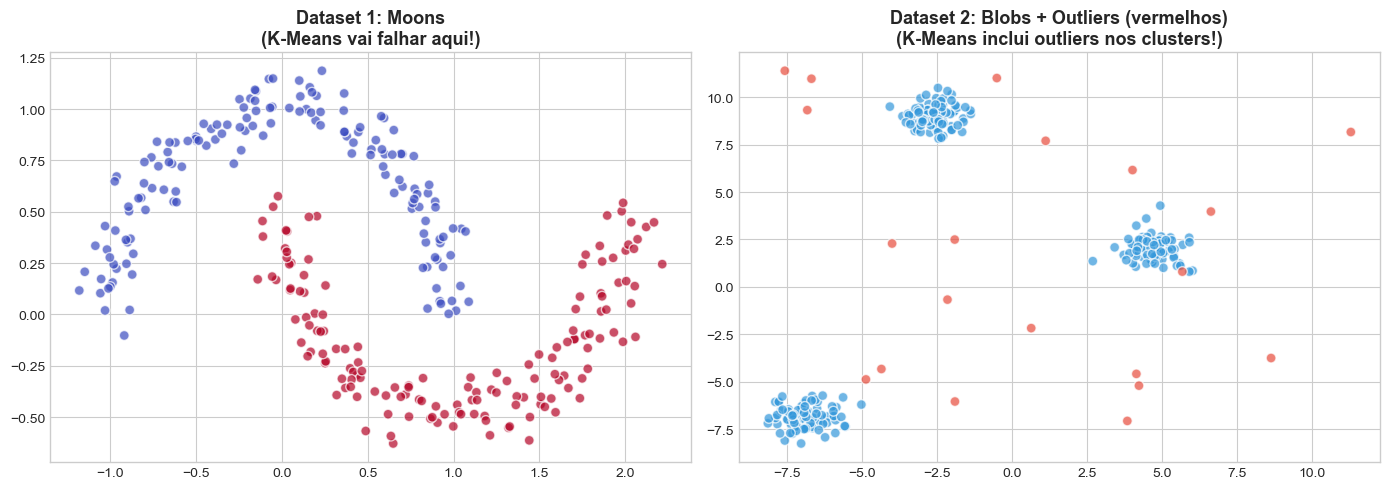

Dataset 1: 300 pontos, 2 luas entrelaçadas
Dataset 2: 250 pontos normais + 20 outliers = 270 total


In [ ]:
# Dataset 1: Moons (duas "luas" entrelaçadas)
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)

# Dataset 2: Blobs com outliers injetados
np.random.seed(42)
X_blobs, y_blobs = make_blobs(n_samples=250, centers=3, cluster_std=0.6, random_state=42)

# Injetar outliers
n_outliers = 20
outliers = np.random.uniform(low=-8, high=12, size=(n_outliers, 2))
X_with_outliers = np.vstack([X_blobs, outliers])
y_with_outliers = np.concatenate([y_blobs, np.full(n_outliers, -1)])  # -1 = outlier real

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', 
                alpha=0.7, edgecolors='white', s=50)
axes[0].set_title('Dataset 1: Moons\n(K-Means vai falhar aqui!)', fontsize=13, fontweight='bold')

colors_real = ['#3498db' if y != -1 else '#e74c3c' for y in y_with_outliers]
axes[1].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=colors_real,
                alpha=0.7, edgecolors='white', s=50)
axes[1].set_title('Dataset 2: Blobs + Outliers (vermelhos)\n(K-Means inclui outliers nos clusters!)', 
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Dataset 1: {X_moons.shape[0]} pontos, 2 luas entrelaçadas')
print(f'Dataset 2: {X_blobs.shape[0]} pontos normais + {n_outliers} outliers = {X_with_outliers.shape[0]} total')

## 3. K-Means Falhando (para motivar o DBSCAN)

Vamos ver K-Means tentar clusterizar as moons — ele vai criar clusters **errados** porque assume formato esférico.

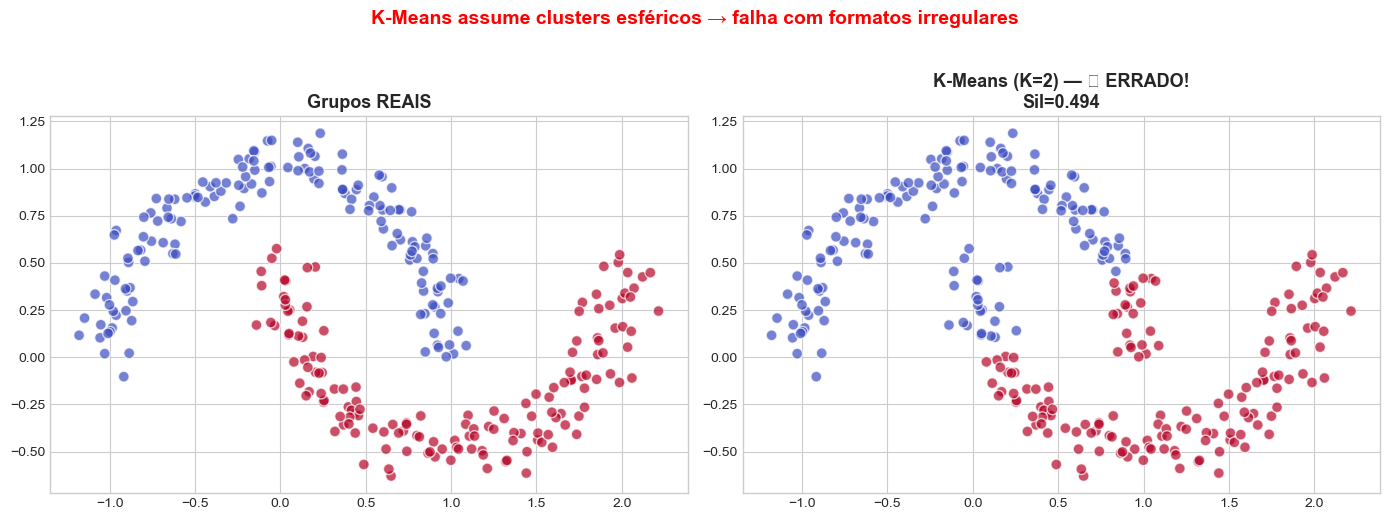

👆 O K-Means cortou as moons ao meio em vez de separá-las!
   Isso acontece porque ele só sabe fazer clusters "redondos".


In [5]:
# K-Means nas Moons — vai falhar!
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans_moons.fit_predict(X_moons_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm',
                alpha=0.7, edgecolors='white', s=60)
axes[0].set_title('Grupos REAIS', fontsize=13, fontweight='bold')

# K-Means
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_labels, cmap='coolwarm',
                alpha=0.7, edgecolors='white', s=60)
axes[1].set_title(f'K-Means (K=2) — ❌ ERRADO!\nSil={silhouette_score(X_moons_scaled, km_labels):.3f}', 
                   fontsize=13, fontweight='bold')

plt.suptitle('K-Means assume clusters esféricos → falha com formatos irregulares', 
             fontsize=14, fontweight='bold', y=1.03, color='red')
plt.tight_layout()
plt.show()

print('👆 O K-Means cortou as moons ao meio em vez de separá-las!')
print('   Isso acontece porque ele só sabe fazer clusters "redondos".')

## 4. DBSCAN: Encontrando eps com k-distance

Antes de rodar DBSCAN, precisamos escolher um bom `eps`.  
O **k-distance plot** mostra a distância ao k-ésimo vizinho mais próximo para cada ponto.

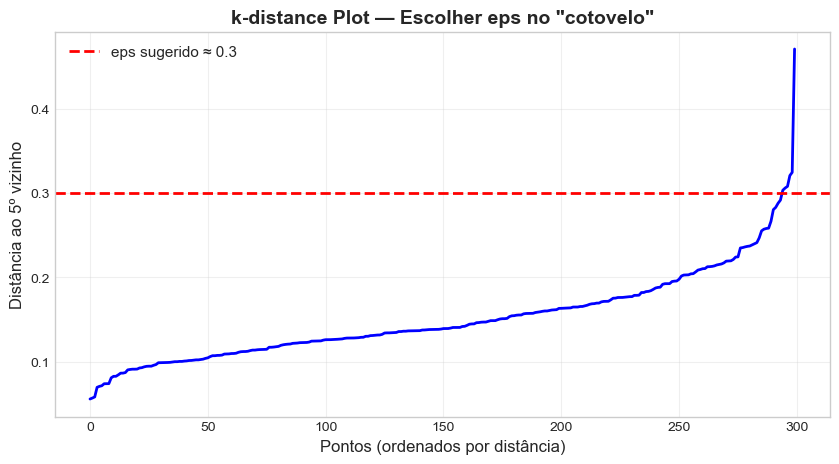

📊 Regra para min_samples: 2 × n_features = 2 × 2 = 4 (usamos 5)
📊 eps sugerido pelo cotovelo: ~0.3
   (onde a curva começa a subir rapidamente)


In [7]:
# k-distance plot para escolher eps
min_samples = 5  # regra de ouro: 2 * n_features = 2*2 = 4, arredondando para 5

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_moons_scaled)
distances, _ = nn.kneighbors(X_moons_scaled)

# Usar a distância ao k-ésimo vizinho (última coluna)
k_distances = np1.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.xlabel('Pontos (ordenados por distância)', fontsize=12)
plt.ylabel(f'Distância ao {min_samples}º vizinho', fontsize=12)
plt.title('k-distance Plot — Escolher eps no "cotovelo"', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Marcar cotovelo sugerido
eps_sugerido = 0.3
plt.axhline(y=eps_sugerido, color='red', linestyle='--', linewidth=2, 
            label=f'eps sugerido ≈ {eps_sugerido}')
plt.legend(fontsize=11)
plt.show()

print(f'📊 Regra para min_samples: 2 × n_features = 2 × 2 = 4 (usamos 5)')
print(f'📊 eps sugerido pelo cotovelo: ~{eps_sugerido}')
print(f'   (onde a curva começa a subir rapidamente)')

## 5. DBSCAN nas Moons — Resultado Correto!

Agora vamos ver o DBSCAN acertar onde o K-Means falhou.

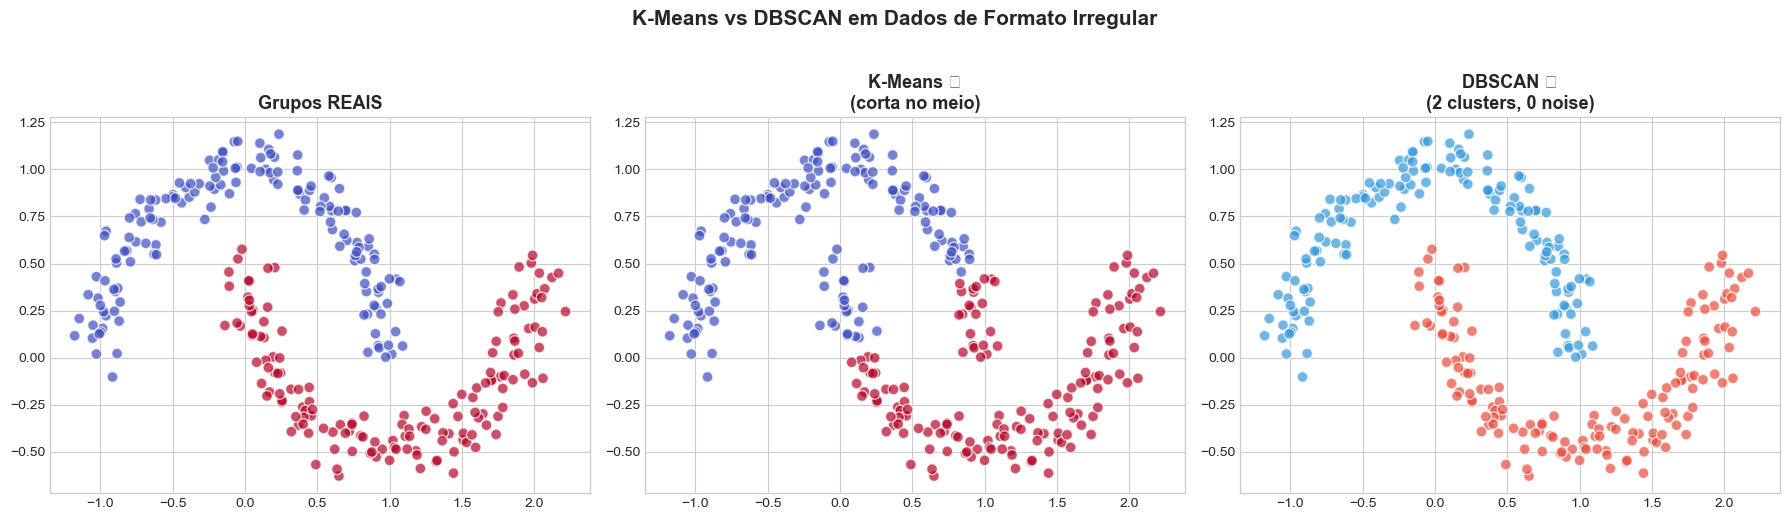


📊 Resultados:
  K-Means:  Silhouette = 0.494 (errado!)
  DBSCAN:   Clusters = 2, Noise = 0, Silhouette = 0.380

🎯 DBSCAN conseguiu separar as duas luas corretamente!


In [8]:
# DBSCAN nas Moons
dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan_moons.fit_predict(X_moons_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()

# Comparar os 3 métodos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm',
                alpha=0.7, edgecolors='white', s=60)
axes[0].set_title('Grupos REAIS', fontsize=13, fontweight='bold')

# K-Means
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_labels, cmap='coolwarm',
                alpha=0.7, edgecolors='white', s=60)
axes[1].set_title('K-Means ❌\n(corta no meio)', fontsize=13, fontweight='bold')

# DBSCAN
colors_db = ['#e74c3c' if l == 0 else '#3498db' if l == 1 else '#333333' for l in db_labels]
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=colors_db,
                alpha=0.7, edgecolors='white', s=60)
axes[2].set_title(f'DBSCAN ✅\n({n_clusters_db} clusters, {n_noise_db} noise)', 
                   fontsize=13, fontweight='bold')

plt.suptitle('K-Means vs DBSCAN em Dados de Formato Irregular', 
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

sil_db = silhouette_score(X_moons_scaled, db_labels) if n_clusters_db > 1 else 0
print(f'\n📊 Resultados:')
print(f'  K-Means:  Silhouette = {silhouette_score(X_moons_scaled, km_labels):.3f} (errado!)')
print(f'  DBSCAN:   Clusters = {n_clusters_db}, Noise = {n_noise_db}, Silhouette = {sil_db:.3f}')
print(f'\n🎯 DBSCAN conseguiu separar as duas luas corretamente!')

## 6. DBSCAN com Outliers

Agora vamos testar no dataset com **outliers injetados** — DBSCAN deve identificá-los como noise.

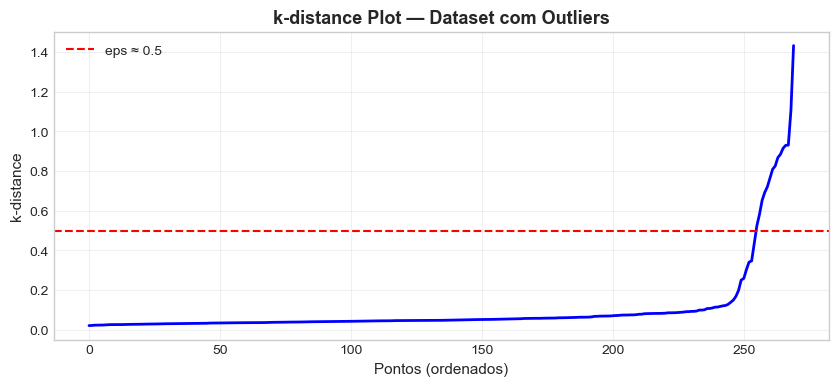

In [9]:
# Escalar dataset com outliers
scaler2 = StandardScaler()
X_out_scaled = scaler2.fit_transform(X_with_outliers)

# k-distance para encontrar eps
nn2 = NearestNeighbors(n_neighbors=5)
nn2.fit(X_out_scaled)
dist2, _ = nn2.kneighbors(X_out_scaled)
k_dist2 = np1.sort(dist2[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist2, 'b-', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='eps ≈ 0.5')
plt.xlabel('Pontos (ordenados)', fontsize=11)
plt.ylabel('k-distance', fontsize=11)
plt.title('k-distance Plot — Dataset com Outliers', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

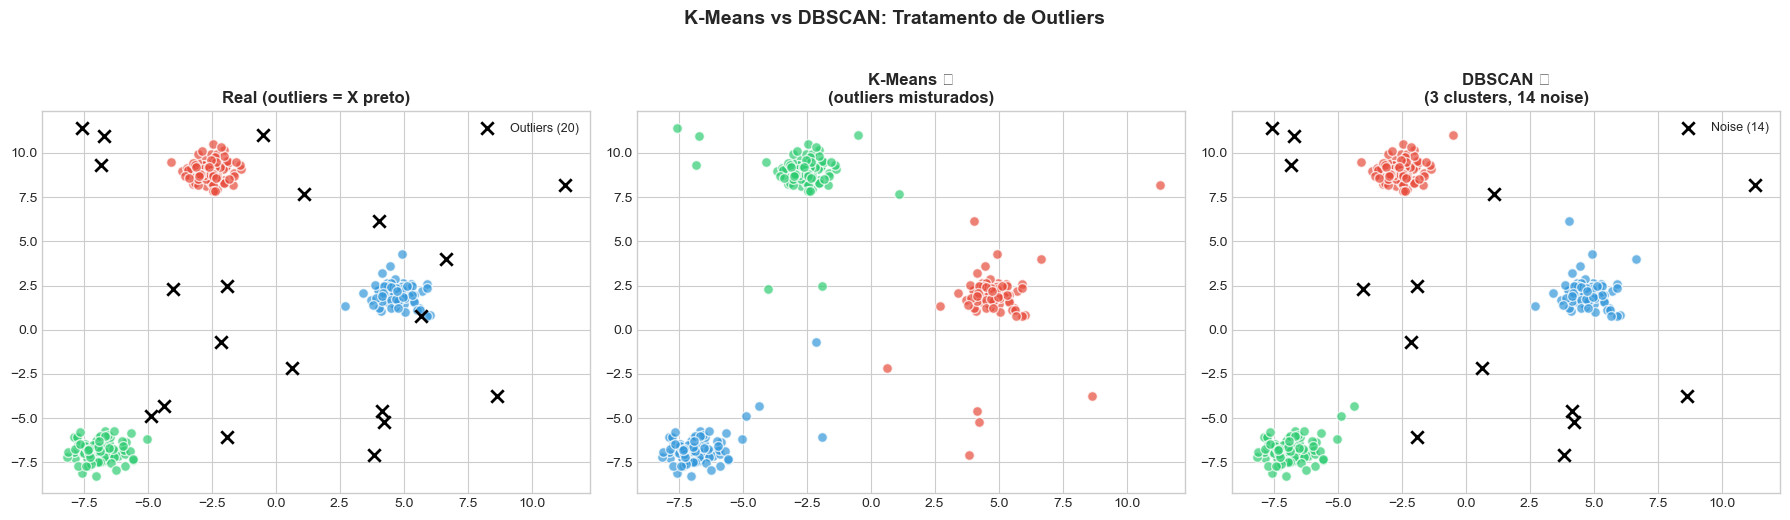


📊 Detecção de Outliers pelo DBSCAN:
  Outliers reais: 20
  Noise detectado: 14
  Outliers corretamente detectados: 14/20


In [10]:
# DBSCAN no dataset com outliers
dbscan_out = DBSCAN(eps=0.5, min_samples=5)
db_out_labels = dbscan_out.fit_predict(X_out_scaled)

n_clusters_out = len(set(db_out_labels)) - (1 if -1 in db_out_labels else 0)
n_noise_out = (db_out_labels == -1).sum()

# Comparar K-Means vs DBSCAN
kmeans_out = KMeans(n_clusters=3, random_state=42, n_init=10)
km_out_labels = kmeans_out.fit_predict(X_out_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Real (outliers em cinza)
for i in range(3):
    mask = y_with_outliers == i
    axes[0].scatter(X_with_outliers[mask, 0], X_with_outliers[mask, 1],
                    c=colors_map[i], alpha=0.7, edgecolors='white', s=50)
mask_out = y_with_outliers == -1
axes[0].scatter(X_with_outliers[mask_out, 0], X_with_outliers[mask_out, 1],
                c='black', marker='x', s=80, linewidths=2, label=f'Outliers ({mask_out.sum()})')
axes[0].set_title('Real (outliers = X preto)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# K-Means (inclui outliers nos clusters!)
for i in range(3):
    mask = km_out_labels == i
    axes[1].scatter(X_with_outliers[mask, 0], X_with_outliers[mask, 1],
                    c=colors_map[i], alpha=0.7, edgecolors='white', s=50)
axes[1].set_title('K-Means ❌\n(outliers misturados)', fontsize=12, fontweight='bold')

# DBSCAN (outliers = noise!)
for i in range(n_clusters_out):
    mask = db_out_labels == i
    axes[2].scatter(X_with_outliers[mask, 0], X_with_outliers[mask, 1],
                    c=colors_map[i], alpha=0.7, edgecolors='white', s=50)
mask_noise = db_out_labels == -1
axes[2].scatter(X_with_outliers[mask_noise, 0], X_with_outliers[mask_noise, 1],
                c='black', marker='x', s=80, linewidths=2, label=f'Noise ({mask_noise.sum()})')
axes[2].set_title(f'DBSCAN ✅\n({n_clusters_out} clusters, {n_noise_out} noise)', 
                   fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('K-Means vs DBSCAN: Tratamento de Outliers', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Quantos outliers reais foram detectados como noise?
real_outliers = set(np1.where(y_with_outliers == -1)[0])
detected_noise = set(np1.where(db_out_labels == -1)[0])
correctly_detected = real_outliers.intersection(detected_noise)

print(f'\n📊 Detecção de Outliers pelo DBSCAN:')
print(f'  Outliers reais: {len(real_outliers)}')
print(f'  Noise detectado: {len(detected_noise)}')
print(f'  Outliers corretamente detectados: {len(correctly_detected)}/{len(real_outliers)}')

## 7. Sensibilidade do eps: O que acontece quando erramos?

Vamos ver o efeito de eps muito pequeno vs muito grande.

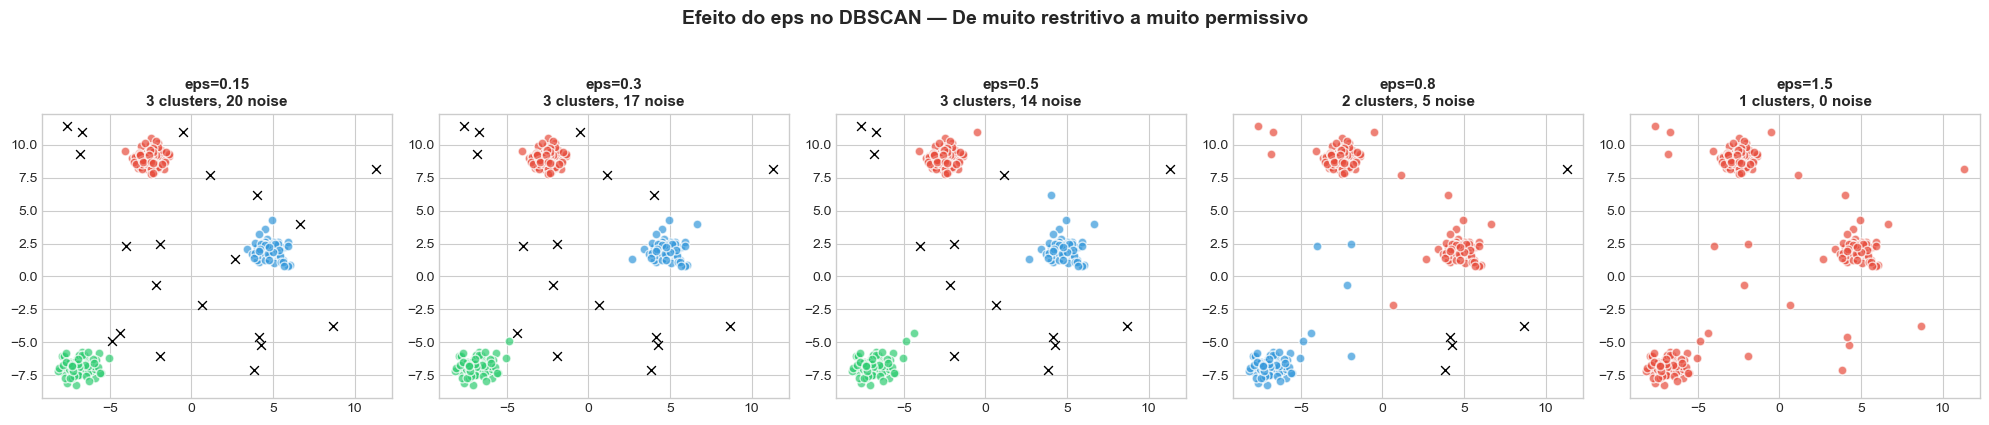

📖 Observação:
  eps muito pequeno → tudo vira noise (muitos clusters pequenos)
  eps muito grande → tudo vira 1 cluster (outliers incluídos)
  eps ideal → clusters corretos + outliers como noise


In [11]:
# Testar diferentes valores de eps
eps_values = [0.15, 0.3, 0.5, 0.8, 1.5]

fig, axes = plt.subplots(1, len(eps_values), figsize=(20, 4))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_out_scaled)
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = (labels == -1).sum()
    
    # Colorir clusters
    unique_labels = sorted(set(labels))
    for l in unique_labels:
        mask = labels == l
        if l == -1:
            ax.scatter(X_with_outliers[mask, 0], X_with_outliers[mask, 1],
                      c='black', marker='x', s=40, linewidths=1)
        else:
            ax.scatter(X_with_outliers[mask, 0], X_with_outliers[mask, 1],
                      c=colors_map[l % len(colors_map)], alpha=0.7, edgecolors='white', s=40)
    
    ax.set_title(f'eps={eps}\n{n_c} clusters, {n_n} noise', fontsize=11, fontweight='bold')

plt.suptitle('Efeito do eps no DBSCAN — De muito restritivo a muito permissivo', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('📖 Observação:')
print('  eps muito pequeno → tudo vira noise (muitos clusters pequenos)')
print('  eps muito grande → tudo vira 1 cluster (outliers incluídos)')
print('  eps ideal → clusters corretos + outliers como noise')

---

## 8. Detecção de Anomalias: Isolation Forest

Agora vamos usar técnicas **dedicadas** para encontrar outliers.  
O Isolation Forest funciona por uma ideia simples: **anomalias são mais fáceis de isolar**.

In [12]:
# Isolation Forest no dataset com outliers
iso_forest = IsolationForest(
    contamination=0.08,   # ~8% esperados como anomalias (20/270)
    random_state=42,
    n_estimators=100
)

# Treinar e prever (-1 = anomalia, 1 = normal)
iso_pred = iso_forest.fit_predict(X_out_scaled)
iso_scores = iso_forest.decision_function(X_out_scaled)  # score de anomalia

n_iso_anomalies = (iso_pred == -1).sum()
print(f'🔍 Isolation Forest:')
print(f'  Anomalias detectadas: {n_iso_anomalies}/{len(X_out_scaled)}')
print(f'  Proporção: {n_iso_anomalies/len(X_out_scaled):.1%}')

# Acurácia na detecção
iso_anomaly_set = set(np1.where(iso_pred == -1)[0])
iso_correct = real_outliers.intersection(iso_anomaly_set)
print(f'\n  Outliers reais encontrados: {len(iso_correct)}/{len(real_outliers)}')
print(f'  Falsos positivos: {len(iso_anomaly_set) - len(iso_correct)}')

🔍 Isolation Forest:
  Anomalias detectadas: 22/270
  Proporção: 8.1%

  Outliers reais encontrados: 19/20
  Falsos positivos: 3


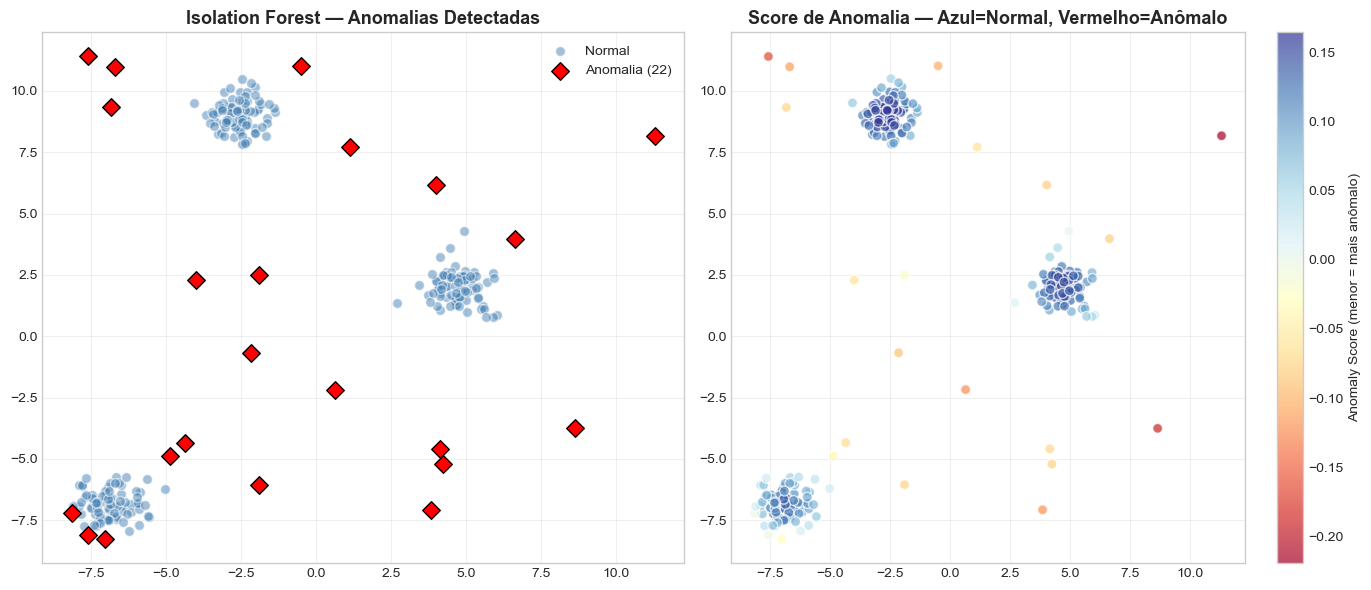

In [13]:
# Visualizar Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Anomalias detectadas
normal_mask = iso_pred == 1
anomaly_mask = iso_pred == -1

axes[0].scatter(X_with_outliers[normal_mask, 0], X_with_outliers[normal_mask, 1],
                c='steelblue', alpha=0.5, edgecolors='white', s=50, label='Normal')
axes[0].scatter(X_with_outliers[anomaly_mask, 0], X_with_outliers[anomaly_mask, 1],
                c='red', marker='D', s=80, linewidths=1, edgecolors='black',
                label=f'Anomalia ({n_iso_anomalies})')
axes[0].set_title('Isolation Forest — Anomalias Detectadas', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Score de anomalia (heatmap)
scatter = axes[1].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1],
                          c=iso_scores, cmap='RdYlBu', alpha=0.7, edgecolors='white', s=50)
plt.colorbar(scatter, ax=axes[1], label='Anomaly Score (menor = mais anômalo)')
axes[1].set_title('Score de Anomalia — Azul=Normal, Vermelho=Anômalo', 
                   fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Detecção de Anomalias: LOF (Local Outlier Factor)

LOF compara a **densidade local** de cada ponto com a dos vizinhos.  
Se um ponto está em região menos densa que seus vizinhos → **anomalia**.

In [14]:
# LOF
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.08
)

lof_pred = lof.fit_predict(X_out_scaled)
lof_scores = lof.negative_outlier_factor_  # quanto mais negativo, mais anômalo

n_lof_anomalies = (lof_pred == -1).sum()
lof_anomaly_set = set(np1.where(lof_pred == -1)[0])
lof_correct = real_outliers.intersection(lof_anomaly_set)

print(f'🔍 LOF (Local Outlier Factor):')
print(f'  Anomalias detectadas: {n_lof_anomalies}/{len(X_out_scaled)}')
print(f'  Outliers reais encontrados: {len(lof_correct)}/{len(real_outliers)}')
print(f'  Falsos positivos: {len(lof_anomaly_set) - len(lof_correct)}')

🔍 LOF (Local Outlier Factor):
  Anomalias detectadas: 22/270
  Outliers reais encontrados: 19/20
  Falsos positivos: 3


## 10. Comparação: DBSCAN vs Isolation Forest vs LOF

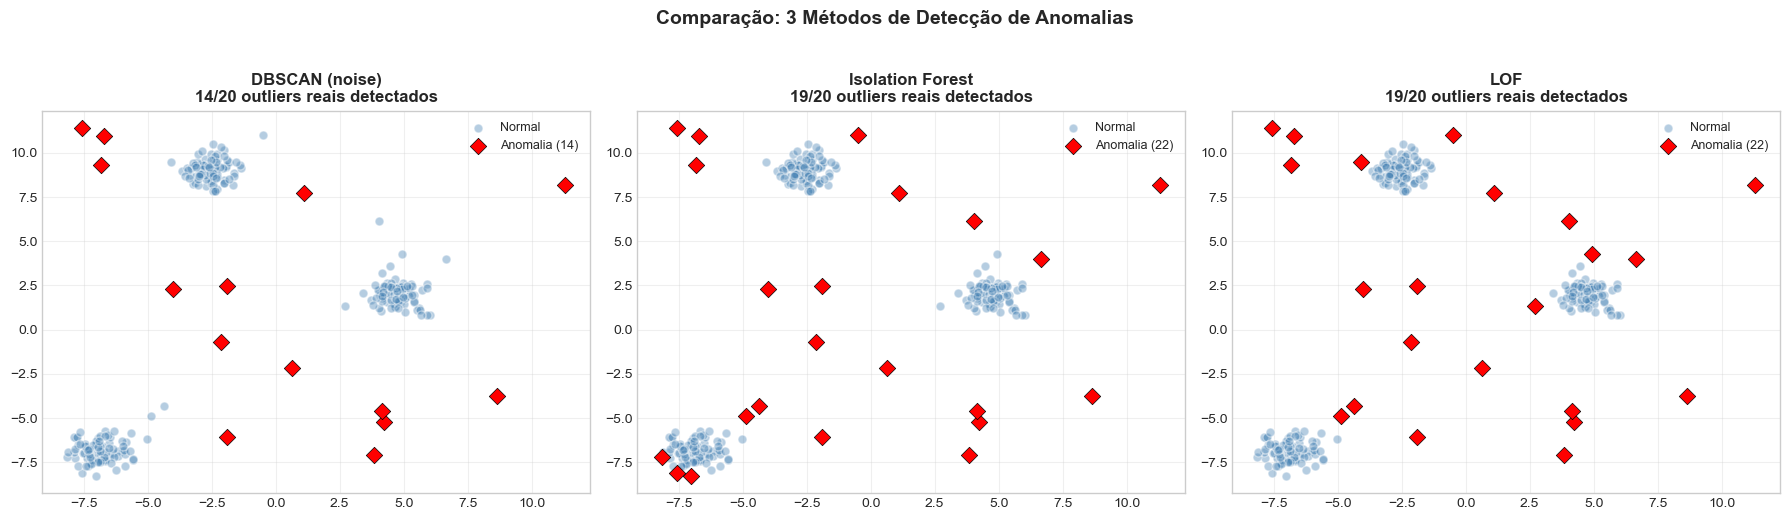


📊 Comparação Detalhada:
Método               Detectadas   Corretas    Falsos+
-----------------------------------------------------------------
DBSCAN (noise)               14         14          0
Isolation Forest             22         19          3
LOF                          22         19          3
Outliers reais:              20


In [15]:
# Comparar os 3 métodos de detecção de anomalias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = [
    ('DBSCAN (noise)', db_out_labels == -1, n_noise_out, len(correctly_detected)),
    ('Isolation Forest', iso_pred == -1, n_iso_anomalies, len(iso_correct)),
    ('LOF', lof_pred == -1, n_lof_anomalies, len(lof_correct)),
]

for ax, (name, anomaly_mask, n_anom, n_correct) in zip(axes, methods):
    normal = ~anomaly_mask
    ax.scatter(X_with_outliers[normal, 0], X_with_outliers[normal, 1],
              c='steelblue', alpha=0.4, edgecolors='white', s=40, label='Normal')
    ax.scatter(X_with_outliers[anomaly_mask, 0], X_with_outliers[anomaly_mask, 1],
              c='red', marker='D', s=70, edgecolors='black', linewidths=0.5,
              label=f'Anomalia ({n_anom})')
    ax.set_title(f'{name}\n{n_correct}/{len(real_outliers)} outliers reais detectados', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparação: 3 Métodos de Detecção de Anomalias', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Tabela comparativa
print('\n📊 Comparação Detalhada:')
print('=' * 65)
print(f'{"Método":<20} {"Detectadas":>10} {"Corretas":>10} {"Falsos+":>10}')
print('-' * 65)
for name, _, n_anom, n_correct in methods:
    fp = n_anom - n_correct
    print(f'{name:<20} {n_anom:>10} {n_correct:>10} {fp:>10}')
print('=' * 65)
print(f'{"Outliers reais:":<20} {len(real_outliers):>10}')

## 11. PCA Aprofundado: Redução + Visualização

Quando temos **muitas features**, PCA ajuda a:
1. Reduzir dimensões para visualizar em 2D
2. Remover ruído (componentes com pouca variância)
3. Melhorar performance de clustering

In [16]:
# Criar dataset com MUITAS features para demonstrar PCA
np1.random.seed(42)

# 8 features: 3 informativas + 5 ruído
X_multi, y_multi = make_blobs(n_samples=300, centers=4, n_features=3, 
                               cluster_std=1.0, random_state=42)

# Adicionar features de ruído
noise = np1.random.randn(300, 5) * 2
X_multi_full = np1.hstack([X_multi, noise])

# Escalar
scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(X_multi_full)

print(f'📊 Dataset com alta dimensionalidade:')
print(f'  Shape: {X_multi_full.shape} (300 pontos, 8 features)')
print(f'  Features informativas: 3')
print(f'  Features de ruído: 5')
print(f'  Clusters reais: 4')

📊 Dataset com alta dimensionalidade:
  Shape: (300, 8) (300 pontos, 8 features)
  Features informativas: 3
  Features de ruído: 5
  Clusters reais: 4


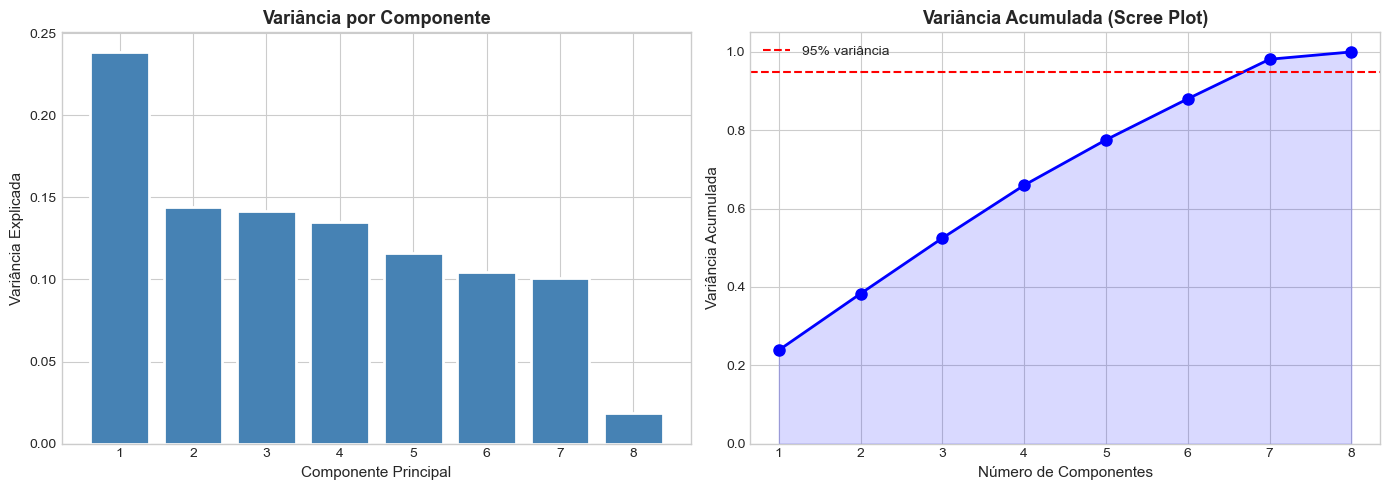


📊 Variância explicada por componente:
  PC1: 0.239 (23.9%)  | Acumulada: 0.239 (23.9%)
  PC2: 0.144 (14.4%)  | Acumulada: 0.383 (38.3%)
  PC3: 0.142 (14.2%)  | Acumulada: 0.525 (52.5%)
  PC4: 0.135 (13.5%)  | Acumulada: 0.660 (66.0%)
  PC5: 0.116 (11.6%)  | Acumulada: 0.776 (77.6%)
  PC6: 0.105 (10.5%)  | Acumulada: 0.880 (88.0%)
  PC7: 0.101 (10.1%)  | Acumulada: 0.981 (98.1%) ←
  PC8: 0.019 (1.9%)  | Acumulada: 1.000 (100.0%)

🎯 Para 95% da variância: 7 componentes (de 8 originais)
   Redução: 8 → 7 features (12% menos dimensões!)


In [17]:
# PCA: variância explicada
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_multi_scaled)

# Plot de variância explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual
axes[0].bar(range(1, 9), pca_full.explained_variance_ratio_, 
            color='steelblue', edgecolor='white', linewidth=2)
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Variância Explicada', fontsize=11)
axes[0].set_title('Variância por Componente', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 9))

# Acumulada
cumvar = np1.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 9), cumvar, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% variância')
axes[1].fill_between(range(1, 9), cumvar, alpha=0.15, color='blue')
axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Variância Acumulada', fontsize=11)
axes[1].set_title('Variância Acumulada (Scree Plot)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 9))
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

n_95 = np1.argmax(cumvar >= 0.95) + 1
print(f'\n📊 Variância explicada por componente:')
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar)):
    marker = ' ←' if i + 1 == n_95 else ''
    print(f'  PC{i+1}: {var:.3f} ({var*100:.1f}%)  | Acumulada: {cum:.3f} ({cum*100:.1f}%){marker}')
print(f'\n🎯 Para 95% da variância: {n_95} componentes (de 8 originais)')
print(f'   Redução: {8} → {n_95} features ({(1-n_95/8)*100:.0f}% menos dimensões!)')

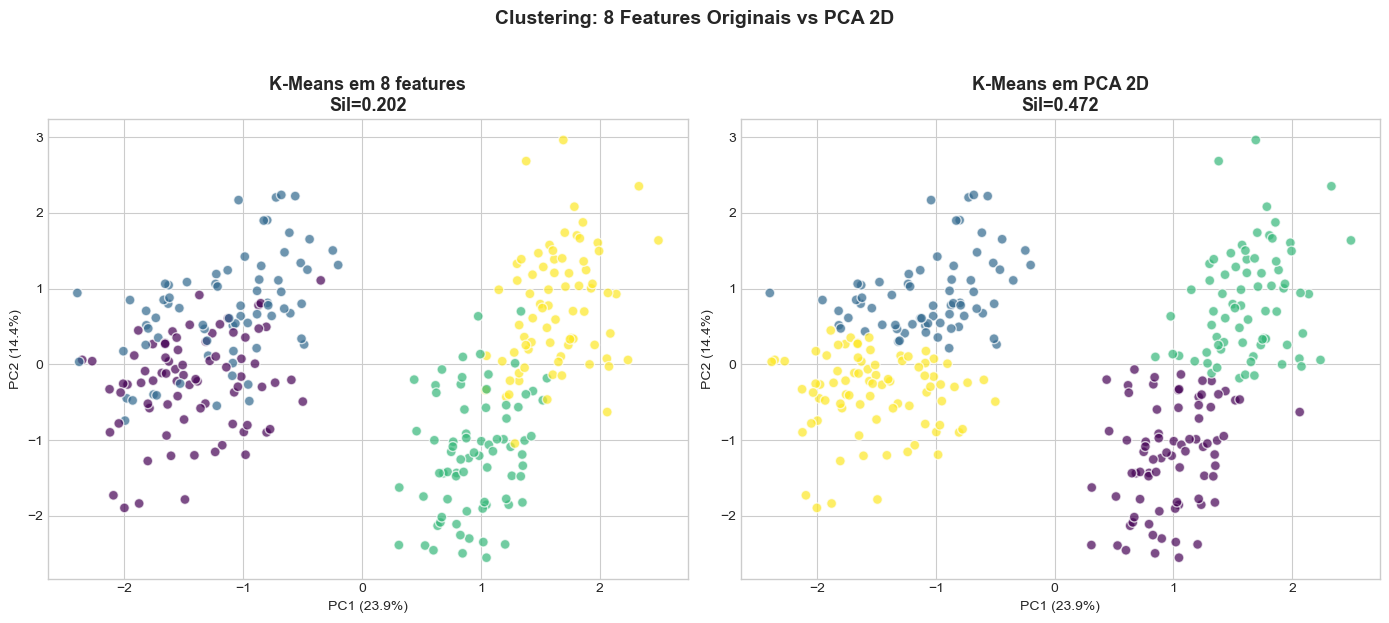


📊 Silhouette Score:
  8 features originais: 0.2023
  PCA 2D:              0.4718
  Diferença: +133.2%

💡 PCA removeu as 5 features de ruído, melhorando o clustering!


In [18]:
# PCA 2D + Clustering: comparar com e sem PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_multi_scaled)

# K-Means nos dados originais (8 features)
km_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_orig = km_orig.fit_predict(X_multi_scaled)
sil_orig = silhouette_score(X_multi_scaled, labels_orig)

# K-Means nos dados PCA (2 features)
km_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_pca_2d)
sil_pca = silhouette_score(X_pca_2d, labels_pca)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original projetado em 2D (apenas para visualização)
X_viz = pca_2d.transform(X_multi_scaled)  # projetar para ver
axes[0].scatter(X_viz[:, 0], X_viz[:, 1], c=labels_orig, cmap='viridis',
                alpha=0.7, edgecolors='white', s=50)
axes[0].set_title(f'K-Means em 8 features\nSil={sil_orig:.3f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

# PCA 2D clustering
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_pca, cmap='viridis',
                alpha=0.7, edgecolors='white', s=50)
axes[1].set_title(f'K-Means em PCA 2D\nSil={sil_pca:.3f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

plt.suptitle('Clustering: 8 Features Originais vs PCA 2D', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'\n📊 Silhouette Score:')
print(f'  8 features originais: {sil_orig:.4f}')
print(f'  PCA 2D:              {sil_pca:.4f}')
improvement = ((sil_pca - sil_orig) / sil_orig) * 100
print(f'  Diferença: {improvement:+.1f}%')
print(f'\n💡 PCA removeu as 5 features de ruído, melhorando o clustering!')

## 12. Combinação: PCA + DBSCAN + Anomaly Detection

Combinando tudo que aprendemos em um pipeline completo.

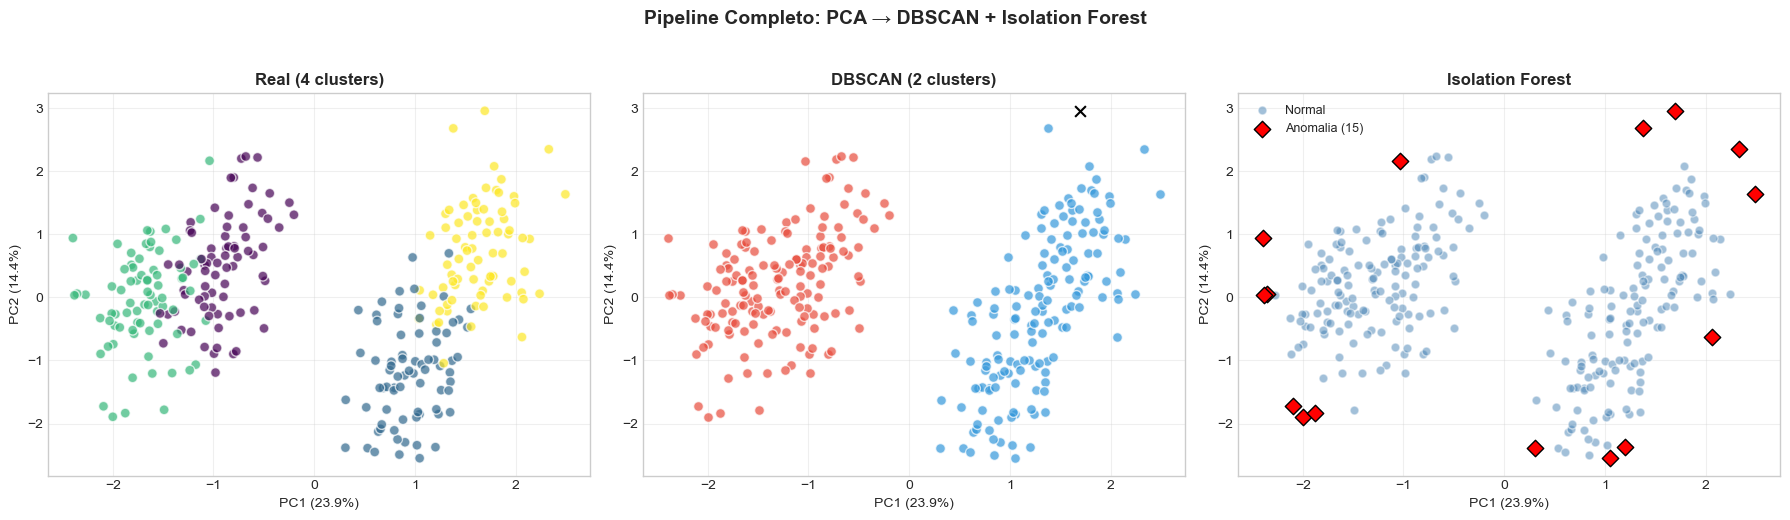


✅ Pipeline: 8 features → PCA 2D → DBSCAN (2 clusters) + Isolation Forest (15 anomalias)


In [19]:
# Pipeline completo: PCA → DBSCAN + Isolation Forest

# 1. PCA para reduzir dimensionalidade
pca_pipe = PCA(n_components=2)
X_pipe = pca_pipe.fit_transform(X_multi_scaled)

# 2. DBSCAN para clustering
dbscan_pipe = DBSCAN(eps=0.8, min_samples=5)
cluster_labels = dbscan_pipe.fit_predict(X_pipe)
n_clusters_pipe = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

# 3. Isolation Forest para anomalias
iso_pipe = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_pipe.fit_predict(X_pipe)

# Visualizar pipeline completo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dados reais
axes[0].scatter(X_pipe[:, 0], X_pipe[:, 1], c=y_multi, cmap='viridis',
                alpha=0.7, edgecolors='white', s=50)
axes[0].set_title('Real (4 clusters)', fontsize=12, fontweight='bold')

# DBSCAN clusters
for i in sorted(set(cluster_labels)):
    mask = cluster_labels == i
    if i == -1:
        axes[1].scatter(X_pipe[mask, 0], X_pipe[mask, 1], c='black', marker='x', s=60)
    else:
        axes[1].scatter(X_pipe[mask, 0], X_pipe[mask, 1], c=colors_map[i % len(colors_map)],
                        alpha=0.7, edgecolors='white', s=50)
axes[1].set_title(f'DBSCAN ({n_clusters_pipe} clusters)', fontsize=12, fontweight='bold')

# Anomalias
normal = anomaly_labels == 1
anomaly = anomaly_labels == -1
axes[2].scatter(X_pipe[normal, 0], X_pipe[normal, 1], c='steelblue', alpha=0.5, 
                edgecolors='white', s=40, label='Normal')
axes[2].scatter(X_pipe[anomaly, 0], X_pipe[anomaly, 1], c='red', marker='D', s=70,
                edgecolors='black', label=f'Anomalia ({anomaly.sum()})')
axes[2].set_title('Isolation Forest', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca_pipe.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_pipe.explained_variance_ratio_[1]:.1%})')
    ax.grid(True, alpha=0.3)

plt.suptitle('Pipeline Completo: PCA → DBSCAN + Isolation Forest', 
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'\n✅ Pipeline: 8 features → PCA 2D → DBSCAN ({n_clusters_pipe} clusters) + Isolation Forest ({anomaly.sum()} anomalias)')

## 13. Resumo e Próximos Passos

### O que Aprendemos Hoje

| Conceito | Status |
|----------|--------|
| DBSCAN (density-based clustering) | ✅ |
| eps + min_samples + k-distance plot | ✅ |
| K-Means vs DBSCAN (quando usar cada) | ✅ |
| Isolation Forest (anomaly detection) | ✅ |
| LOF (local outlier factor) | ✅ |
| Comparação de 3 métodos de anomalias | ✅ |
| PCA aprofundado (variância explicada) | ✅ |
| Pipeline: PCA + DBSCAN + Anomaly Det. | ✅ |

In [20]:
# Resumo final
print('=' * 60)
print('📊 RESUMO — Dia 2: DBSCAN + Detecção de Anomalias')
print('=' * 60)

print(f'\n🔹 DBSCAN (Moons dataset):')
print(f'  Clusters encontrados: {n_clusters_db} (sem definir K!)')
print(f'  Noise detectado: {n_noise_db} pontos')
print(f'  K-Means errou neste dataset, DBSCAN acertou ✅')

print(f'\n🔹 DBSCAN (dataset com outliers):')
print(f'  Clusters: {n_clusters_out}')
print(f'  Outliers reais detectados como noise: {len(correctly_detected)}/{len(real_outliers)}')

print(f'\n🔹 Detecção de Anomalias:')
print(f'  Isolation Forest: {len(iso_correct)}/{len(real_outliers)} outliers detectados')
print(f'  LOF: {len(lof_correct)}/{len(real_outliers)} outliers detectados')

print(f'\n🔹 PCA:')
print(f'  Redução: 8 → {n_95} features para 95% da variância')
print(f'  Silhouette 8 features: {sil_orig:.4f}')
print(f'  Silhouette PCA 2D:     {sil_pca:.4f}')

print(f'\n✅ Dia 2 concluído!')
print(f'\n📌 Próximo: Dia 3 — Segmentação do Projeto Financeiro')
print(f'   Vamos aplicar tudo (K-Means, DBSCAN, anomalias)')
print(f'   nos dados REAIS de despesas da família!')

📊 RESUMO — Dia 2: DBSCAN + Detecção de Anomalias

🔹 DBSCAN (Moons dataset):
  Clusters encontrados: 2 (sem definir K!)
  Noise detectado: 0 pontos
  K-Means errou neste dataset, DBSCAN acertou ✅

🔹 DBSCAN (dataset com outliers):
  Clusters: 3
  Outliers reais detectados como noise: 14/20

🔹 Detecção de Anomalias:
  Isolation Forest: 19/20 outliers detectados
  LOF: 19/20 outliers detectados

🔹 PCA:
  Redução: 8 → 7 features para 95% da variância
  Silhouette 8 features: 0.2023
  Silhouette PCA 2D:     0.4718

✅ Dia 2 concluído!

📌 Próximo: Dia 3 — Segmentação do Projeto Financeiro
   Vamos aplicar tudo (K-Means, DBSCAN, anomalias)
   nos dados REAIS de despesas da família!
